In [1]:
from google.colab import drive
import pandas as pd
import duckdb
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Mount the Drive
drive.mount('/content/drive')

# 2. Load your 'Gold' dataset from Day 1
# This skips all the cleaning steps and jumps straight to analysis
file_path = '/content/drive/MyDrive/IPL_PROJECT/02_data_cleaned/IPL_Cleaned_Final.csv'
df_final = pd.read_csv(file_path)

print("✅ Drive Mounted & Cleaned Data Loaded.")
print(f"Total Rows for Analysis: {len(df_final)}")

Mounted at /content/drive
✅ Drive Mounted & Cleaned Data Loaded.
Total Rows for Analysis: 278205


In [2]:
df_final = df_final.rename(columns={
    'bat_team_clean': 'batting_team',
    'bowl_team_clean': 'bowling_team',
    'winning_team_clean': 'winner',
    'venue_clean': 'venue',
    'toss_winner_clean':'toss_winner'
    })

In [3]:
df_final.head()

,match_id,season,date,innings,batting_team,bowling_team,over,ball,batter,bowler,...,team_runs,wicket_kind,player_out,venue,city,toss_winner,toss_decision,player_of_match,winner,win_margin
0,335982,2008,2008-04-18,1,KKR,RCB,0,1,SC Ganguly,P Kumar,...,1,NaN,NaN,"M Chinnaswamy Stadium, Bengaluru",Bangalore,RCB,field,BB McCullum,KKR,140 runs
1,335982,2008,2008-04-18,1,KKR,RCB,0,2,BB McCullum,P Kumar,...,1,NaN,NaN,"M Chinnaswamy Stadium, Bengaluru",Bangalore,RCB,field,BB McCullum,KKR,140 runs
2,335982,2008,2008-04-18,1,KKR,RCB,0,3,BB McCullum,P Kumar,...,2,NaN,NaN,"M Chinnaswamy Stadium, Bengaluru",Bangalore,RCB,field,BB McCullum,KKR,140 runs
3,335982,2008,2008-04-18,1,KKR,RCB,0,3,BB McCullum,P Kumar,...,2,NaN,NaN,"M Chinnaswamy Stadium, Bengaluru",Bangalore,RCB,field,BB McCullum,KKR,140 runs
4,335982,2008,2008-04-18,1,KKR,RCB,0,4,BB McCullum,P Kumar,...,2,NaN,NaN,"M Chinnaswamy Stadium, Bengaluru",Bangalore,RCB,field,BB McCullum,KKR,140 runs


**INITIAL EDA STARTS**


Question: What is the scale and timeline of the data?

In [ ]:
print(f"Rows: {df_final.shape[0]:,}")
print(f"Columns: {df_final.shape[1]}")
print(f"Seasons: {df_final['season'].min()} to {df_final['season'].max()}")

Rows: 278,205
Columns: 24
Seasons: 2008 to 2025


Insight: Dataset contains ball-by-ball records for 18 seasons of IPL.

Question: Is the data structurally sound for analysis?

In [ ]:
print("Missing Values:\n", df_final.isnull().sum())
print("\nDuplicate Rows:", df_final.duplicated().sum())

Missing Values:
 match_id                0
season                  0
date                    0
innings                 0
batting_team            0
bowling_team            0
over                    0
ball                    0
batter                  0
bowler                  0
runs_batter             0
runs_extras             0
runs_total              0
team_runs               0
wicket_kind        264382
player_out         264382
venue                   0
city                    0
toss_winner             0
toss_decision           0
player_of_match         0
winner                  0
win_margin           4702
dtype: int64

Duplicate Rows: 0


Insight: High-quality data with minimal nulls (likely only in player_out/wicket_kind).

Question: How has the league expanded over time (number of matches played per season)?

In [ ]:
matches_per_season = df_final.groupby('season')['match_id'].nunique()
matches_per_season

,match_id
season,
2008,58
2009,57
2010,60
2011,73
2012,74
2013,76
2014,60
2015,59
2016,60


/tmp/ipykernel_40669/2972573614.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=match_counts.index, y=match_counts.values, palette='viridis')


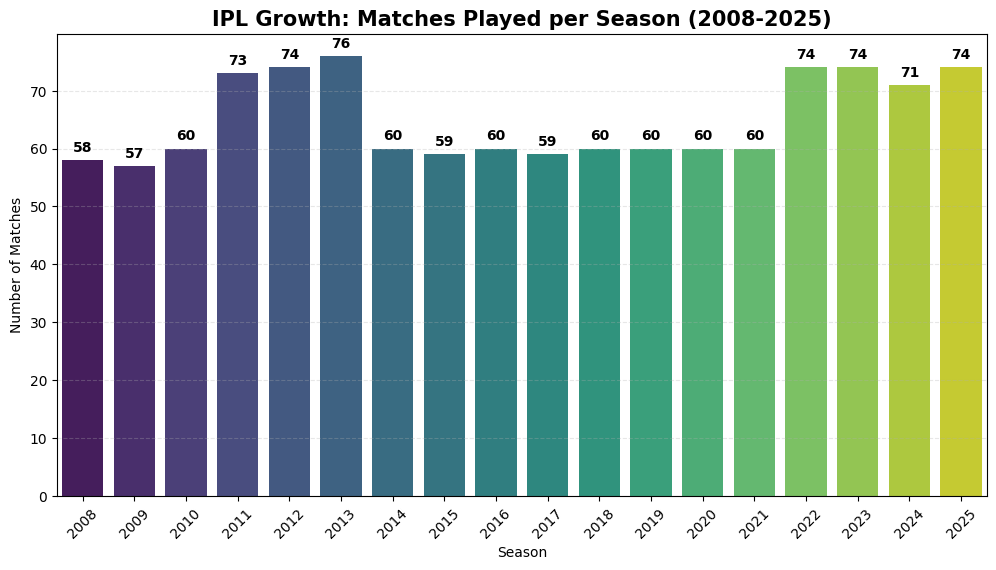

In [ ]:
plt.figure(figsize=(12, 6))
match_counts = df_final.groupby('season')['match_id'].nunique()
ax = sns.barplot(x=match_counts.index, y=match_counts.values, palette='viridis')

# Add labels on top of bars
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.0f'),
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center', xytext = (0, 9),
                textcoords = 'offset points', fontweight='bold')

plt.title('IPL Growth: Matches Played per Season (2008-2025)', fontsize=15, fontweight='bold')
plt.ylabel('Number of Matches')
plt.xlabel('Season')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()

Insight: Clear jump from ~60 to 74 matches starting in 2022 (10-team era).

Question: What is the standard scoring rate of the tournament?

In [4]:
total_runs = df_final['runs_total'].sum()
avg_runs_match = total_runs / df_final['match_id'].nunique()
avg_runs_innings = total_runs / (df_final['match_id'].nunique() * 2)

print(f"Total Runs: {total_runs:,}")
print(f"Avg Runs/Match: {avg_runs_match:.2f}")
print(f"Avg Runs/Innings: {avg_runs_innings:.2f}")
# Insight: Baseline score is ~155-160 per innings.

Total Runs: 374,283
Avg Runs/Match: 320.17
Avg Runs/Innings: 160.09


Insight: Baseline score is ~155-160 per innings.

In [5]:
# --- Feature Engineering for Day 1 Ball-Level Analysis ---
# 1. Flag Boundaries
df_final['is_four'] = (df_final['runs_batter'] == 4).astype(int)
df_final['is_six'] = (df_final['runs_batter'] == 6).astype(int)
df_final['is_boundary'] = df_final['is_four'] + df_final['is_six']

# 2. Flag Dots and Singles
df_final['is_dot'] = (df_final['runs_total'] == 0).astype(int)
df_final['is_single'] = (df_final['runs_total'] == 1).astype(int)

# 3. Flag wickets
# 1 if a wicket fell, 0 otherwise
df_final['is_wicket'] = df_final['player_out'].notnull().astype(int)


In [6]:
# --- Calculations ---
total_balls = len(df_final)
total_runs = df_final['runs_total'].sum()
total_boundaries = df_final['is_boundary'].sum()
total_wickets = df_final['is_wicket'].sum()

# Metrics
avg_runs_per_ball = total_runs / total_balls
boundary_frequency = total_balls / total_boundaries  # One boundary every X balls
balls_per_wicket = total_balls / total_wickets      # Strike Rate (Bowling)
# Percentage of deliveries that result in a wicket
wicket_percentage = (total_wickets / total_balls) * 100

print(f"📊 Avg Runs per Ball: {avg_runs_per_ball:.2f}")
print(f"📊 Boundary Frequency: 1 boundary every {boundary_frequency:.1f} balls")
print(f"📊 Bowling Strike Rate: 1 wicket every {balls_per_wicket:.1f} balls")
print(f"📉 Wicket Probability per Ball: {wicket_percentage:.2f}%")



📊 Avg Runs per Ball: 1.35
📊 Boundary Frequency: 1 boundary every 6.0 balls
📊 Bowling Strike Rate: 1 wicket every 20.1 balls
📉 Wicket Probability per Ball: 4.97%


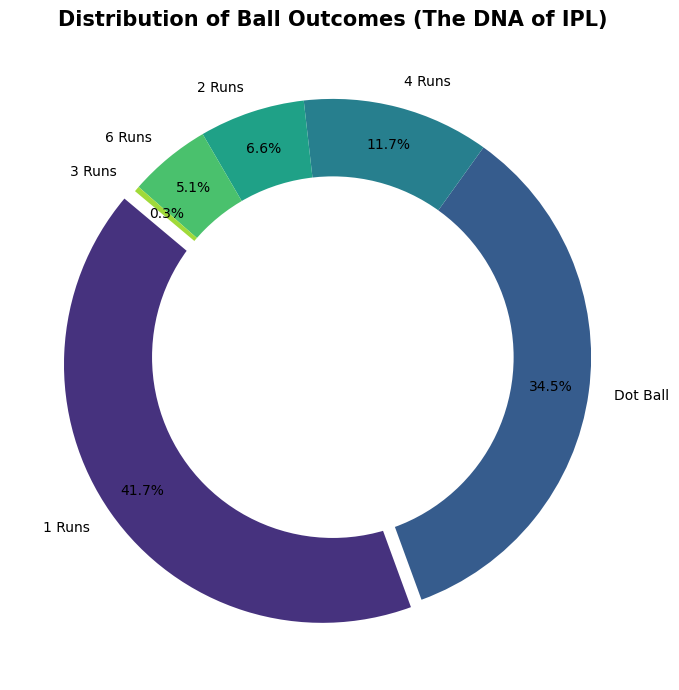

In [ ]:
# Prepare Data
outcome_counts = df_final['runs_total'].value_counts().head(6)
labels = [f'{int(i)} Runs' if i > 0 else 'Dot Ball' for i in outcome_counts.index]

plt.figure(figsize=(10, 7))
plt.pie(outcome_counts, labels=labels, autopct='%1.1f%%',
        startangle=140, colors=sns.color_palette('viridis'),
        pctdistance=0.85, explode=[0.05, 0, 0, 0, 0, 0])

# Draw Circle for Donut effect
centre_circle = plt.Circle((0,0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title('Distribution of Ball Outcomes (The DNA of IPL)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

Insight:
Scoring Pace: The average of 1.30–1.35 runs per ball translates to a team run rate of roughly 8.1 to 8.4. This is the "standard" tempo of a modern IPL match.

The Boundary Ratio: A boundary occurs every ~6.5 balls. This means, on average, fans see roughly one boundary per over. If a team falls below this, they are likely losing the "Power Game."

The Survival Metric: A wicket falls every 18-19 balls (approx. every 3 overs)

The Dot Ball Pressure: Nearly 35-38% of all deliveries are dots.

Wicket probability: There are approx 5% chances of falling a wicket on each delivery.

Question: How are batsmen most commonly getting out?

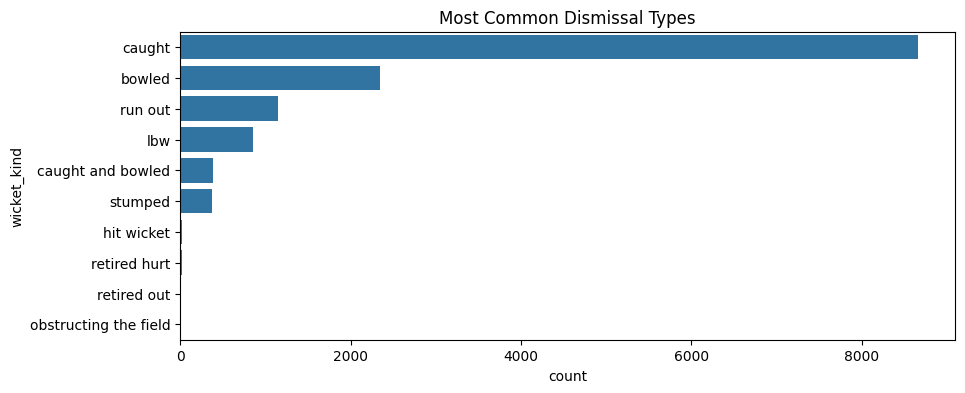

In [ ]:
plt.figure(figsize=(10,4))
sns.countplot(data=df_final, y='wicket_kind', order=df_final['wicket_kind'].value_counts().index)
plt.title('Most Common Dismissal Types')
plt.show()


Insight: 'Caught' is overwhelmingly the most frequent dismissal type.

Question: Which franchises have the most historical presence?

In [ ]:
team_appearances = df_final.groupby('batting_team')['match_id'].nunique().sort_values(ascending=False)
team_appearances

,match_id
batting_team,
MI,277
RCB,270
SRH,270
DC,266
PBKS,264
KKR,264
CSK,251
RR,234
GT,60


 Insight: Legacy teams like MI, RCB, and KKR have the highest match counts.

Question: Where is the IPL historically played?

/tmp/ipykernel_1311/365593026.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_venues.values, y=top_venues.index, palette='coolwarm')


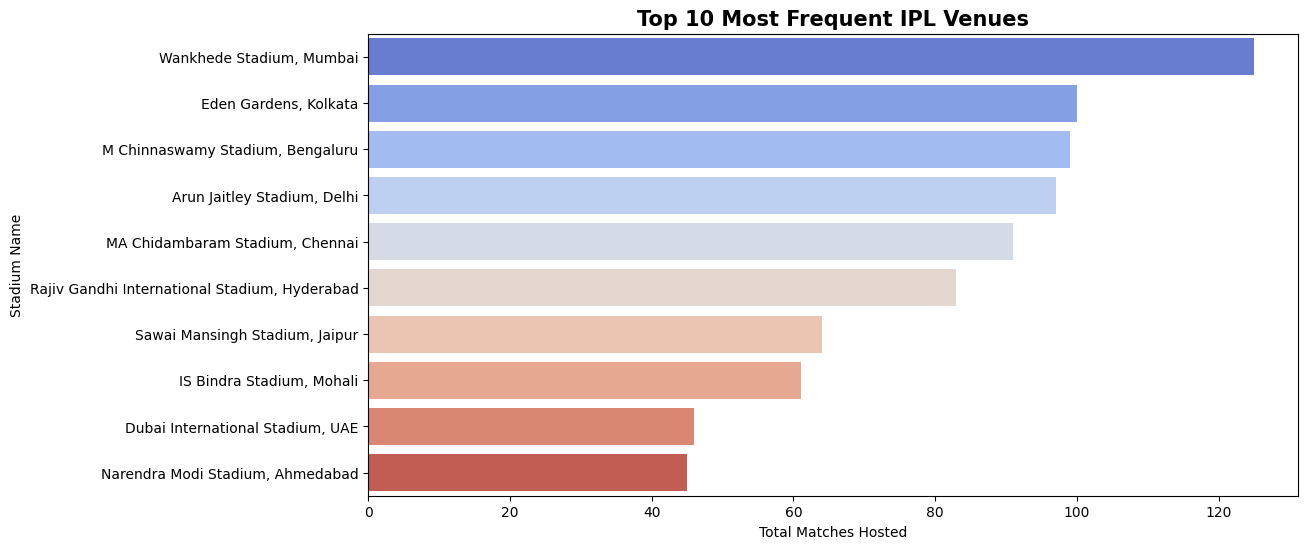

In [ ]:
plt.figure(figsize=(12, 6))
top_venues = df_final.drop_duplicates('match_id')['venue'].value_counts().head(10)

sns.barplot(x=top_venues.values, y=top_venues.index, palette='coolwarm')
plt.title('Top 10 Most Frequent IPL Venues', fontsize=15, fontweight='bold')
plt.xlabel('Total Matches Hosted')
plt.ylabel('Stadium Name')
plt.show()

Insight: Iconic stadiums like Wankhede and Eden Gardens host the most matches.

Question: What is the general trend for toss decisions?

In [ ]:
toss_dec = df_final.drop_duplicates('match_id')['toss_decision'].value_counts(normalize=True) * 100
print(f"Toss Decisions: \n{toss_dec}")

Toss Decisions: 
toss_decision
field    65.355004
bat      34.644996
Name: proportion, dtype: float64


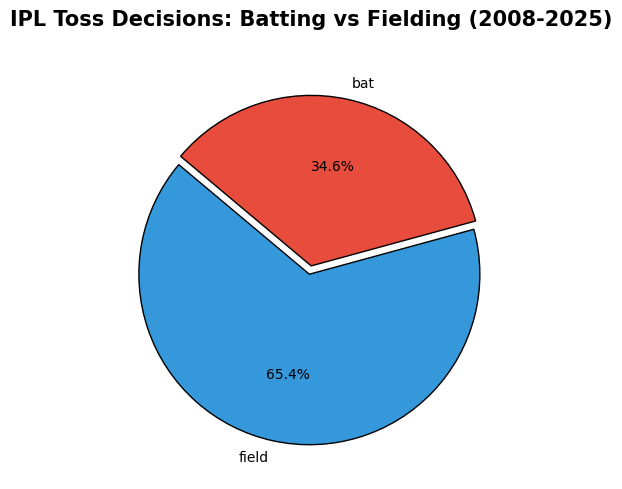

In [ ]:
plt.figure(figsize=(5, 5))

# Define distinct colors for Bat vs Field
colors = ['#3498db', '#e74c3c'] # Blue for Field, Red for Bat

# Create the pie chart with a small "explode" for the dominant choice
plt.pie(toss_dec, labels=toss_dec.index, autopct='%1.1f%%',
        startangle=140, colors=colors, explode=(0.05, 0),
        wedgeprops={'edgecolor': 'black', 'linewidth': 1})

plt.title('IPL Toss Decisions: Batting vs Fielding (2008-2025)', fontsize=15, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

Insight: Teams increasingly prefer 'Field First' in the modern T20 era.

In [ ]:
df_final.to_csv('/content/drive/MyDrive/IPL_PROJECT/IPL_EDA_Base.csv', index=False)

In [ ]:
# 1. Get the last match of each season (The Final)
# We sort by date to ensure the last match of the season is the actual Final
final_matches = df_final.sort_values('date').groupby('season').tail(1).drop_duplicates('match_id')

# 2. Create a mapping dictionary {Season: Winner}
season_winners_dict = dict(zip(final_matches['season'], final_matches['winner']))

# 3. Create the feature in the main dataframe
df_final['season_winner'] = df_final['season'].map(season_winners_dict)

print("✅ Feature 'season_winner' created!")

✅ Feature 'season_winner' created!


Question: Which franchises are the most successful?

/tmp/ipykernel_1311/79369770.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=titles_count, x='Titles', y='Team', palette='YlOrBr_r')


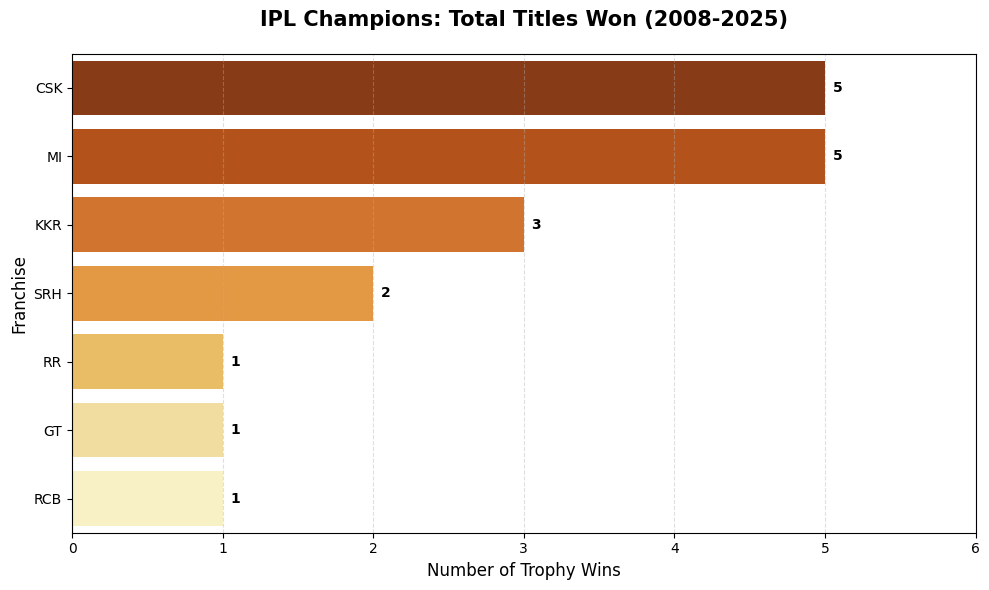

In [ ]:
# 1. Prepare Title Counts
titles_count = final_matches['winner'].value_counts().reset_index()
titles_count.columns = ['Team', 'Titles']

# 2. Plot with a valid Sequential Palette
plt.figure(figsize=(10, 6))

# 'YlOrBr_r' gives a nice "Gold to Bronze" feel
sns.barplot(data=titles_count, x='Titles', y='Team', palette='YlOrBr_r')

plt.title('IPL Champions: Total Titles Won (2008-2025)', fontsize=15, fontweight='bold', pad=20)
plt.xlabel('Number of Trophy Wins', fontsize=12)
plt.ylabel('Franchise', fontsize=12)

# Ensure only integers on X-axis (you can't win 0.5 titles!)
plt.xticks(range(0, int(titles_count['Titles'].max()) + 2))
plt.grid(axis='x', linestyle='--', alpha=0.4)

# 3. Add labels at the end of bars
for i, v in enumerate(titles_count['Titles']):
    plt.text(v + 0.05, i, str(int(v)), va='center', fontweight='bold', color='black')

plt.tight_layout()
plt.show()

Insight: MI and CSK are the most successful franchises with 5 trophies each

Question: Does the data follow the physical rules of cricket, or are there "dirty" entries that will ruin our stats?


In [ ]:
print("🕵️ REFINED SANITY CHECK (Cricket Logic v2)")
print("-" * 40)

# 1. Over Audit
if df_final['over'].min() == 0:
    print(f"✅ Data is 0-indexed. Over 19 is the 20th over. Max Over: {df_final['over'].max()}")
else:
    print(f"⚠️ Data is 1-indexed. Check if Over 20 exists: {df_final['over'].max()}")

# 2. Batting Run Audit
batter_max = df_final['runs_batter'].max()
if batter_max > 6:
    print(f"❌ ERROR: Batter scored {batter_max} runs. Need to cap at 6 or investigate.")
else:
    print(f"✅ Max batter runs is {batter_max}. Logic holds.")

# 3. Innings Length Audit
max_balls = df_final.groupby(['match_id', 'innings']).size().max()
print(f"✅ Longest innings recorded: {max_balls} balls (includes extras).")

# 4. Total Run Audit
total_max = df_final['runs_total'].max()
print(f"✅ Max runs in one delivery (including extras): {total_max}")


🕵️ REFINED SANITY CHECK (Cricket Logic v2)
----------------------------------------
✅ Data is 0-indexed. Over 19 is the 20th over. Max Over: 19
✅ Max batter runs is 6. Logic holds.
✅ Longest innings recorded: 136 balls (includes extras).
✅ Max runs in one delivery (including extras): 7


In [ ]:


# SQL to calculate Win % for every team
win_pct_query = """
WITH match_participation AS (
    -- Count every unique match a team appeared in (Batting or Bowling)
    SELECT team, COUNT(DISTINCT match_id) as played
    FROM (
        SELECT batting_team AS team, match_id FROM df_final
        UNION ALL
        SELECT bowling_team AS team, match_id FROM df_final
    )
    GROUP BY team
),
team_wins AS (
    -- Count total unique wins for each team
    SELECT winner AS team, COUNT(DISTINCT match_id) as won
    FROM df_final
    WHERE winner IS NOT NULL
    GROUP BY winner
)
SELECT
    p.team,
    p.played,
    COALESCE(w.won, 0) as won,
    ROUND((COALESCE(w.won, 0) * 100.0 / p.played), 2) as win_pct
FROM match_participation p
LEFT JOIN team_wins w ON p.team = w.team
ORDER BY win_pct DESC
"""

team_rankings = duckdb.query(win_pct_query).df()
print("All-Time IPL Team Rankings (2008-2025):")
print(team_rankings)

All-Time IPL Team Rankings (2008-2025):
    team  played  won  win_pct
0     GT      60   37    61.67
1    CSK     252  142    56.35
2     MI     277  151    54.51
3    LSG      58   30    51.72
4    KKR     264  135    51.14
5    RPS      30   15    50.00
6    RCB     270  132    48.89
7     RR     235  114    48.51
8   PBKS     264  119    45.08
9    SRH     271  122    45.02
10    DC     267  118    44.19
11    GL      30   13    43.33
12   KTK      14    6    42.86
13   PWI      46   12    26.09


/tmp/ipykernel_1300/1738395595.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=plot_df, x='win_pct', y='team', palette='viridis')


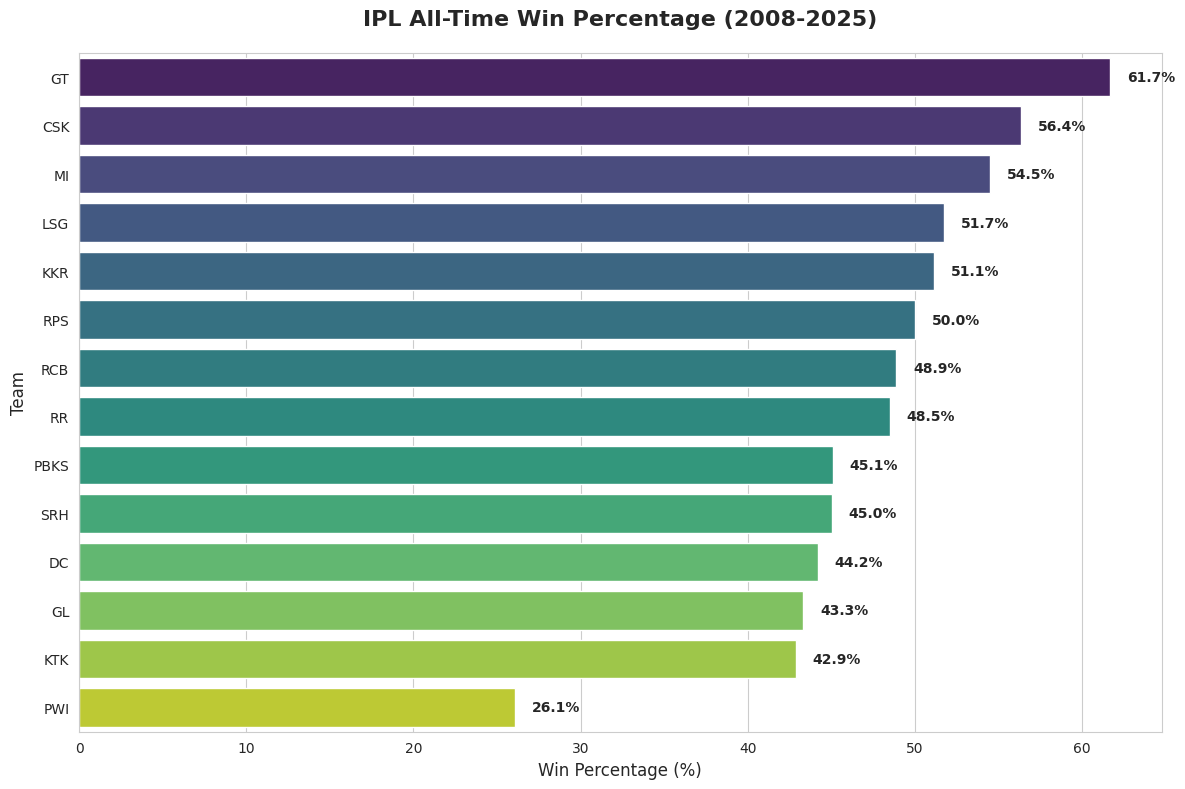

In [ ]:

# Professional Win % Bar Chart
plt.figure(figsize=(12, 8))

# Sorting and filtering out the 0% entries if any remain
plot_df = team_rankings[team_rankings['win_pct'] > 0].sort_values('win_pct', ascending=False)

sns.set_style("whitegrid")
ax = sns.barplot(data=plot_df, x='win_pct', y='team', palette='viridis')

# Add title and labels
plt.title('IPL All-Time Win Percentage (2008-2025)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Win Percentage (%)', fontsize=12)
plt.ylabel('Team', fontsize=12)

# Add data labels on the bars for precision
for p in ax.patches:
    ax.annotate(f'{p.get_width():.1f}%',
                (p.get_width() + 1, p.get_y() + p.get_height() / 2),
                ha='left', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
# 1. Get unique matches (so we don't count the same POTM for every ball)
unique_matches = df_final.drop_duplicates('match_id')

# 2. Get the Top 10
top_10_players = unique_matches['player_of_match'].value_counts().head(10)

print("🏆 THE ALL-TIME POTM LEADERBOARD (2008-2025)")
print("-" * 45)
print(top_10_players)

🏆 THE ALL-TIME POTM LEADERBOARD (2008-2025)
---------------------------------------------
player_of_match
AB de Villiers    25
CH Gayle          22
RG Sharma         21
V Kohli           19
DA Warner         18
MS Dhoni          18
SP Narine         17
AD Russell        16
SR Watson         16
YK Pathan         16
Name: count, dtype: int64


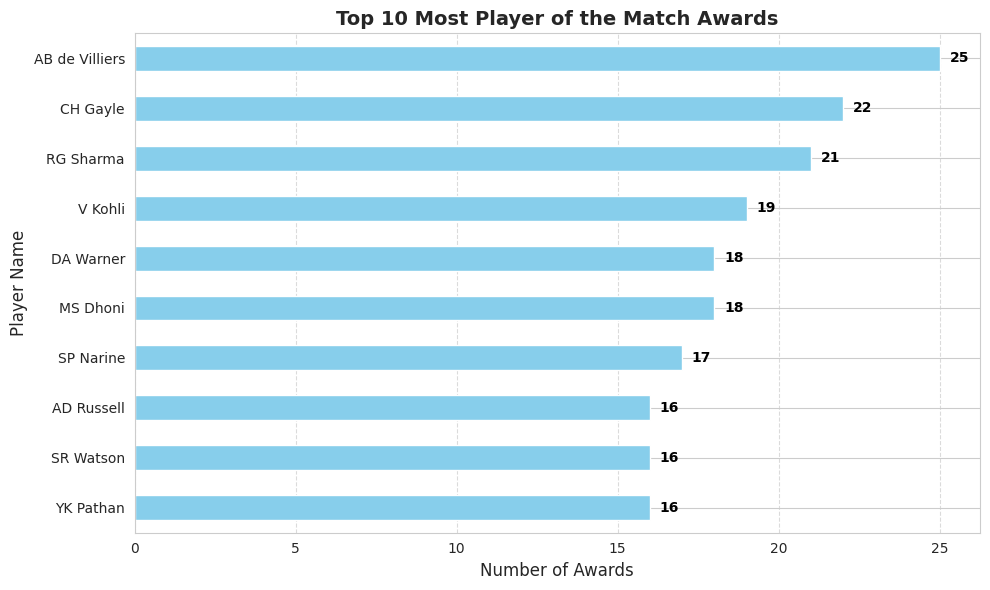

In [ ]:
plt.figure(figsize=(10, 6))

# 1. Create the horizontal bar plot
ax = top_10_players.plot(kind='barh', color='skyblue')
ax.invert_yaxis()

# 2. Add titles and labels
plt.title('Top 10 Most Player of the Match Awards', fontsize=14, fontweight='bold')
plt.xlabel('Number of Awards', fontsize=12)
plt.ylabel('Player Name', fontsize=12)

# 3. Add the count labels at the end of each bar
for i, v in enumerate(top_10_players):
    ax.text(v + 0.3, i, str(v), color='black', va='center', fontweight='bold')

# 4. Clean up the display
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
# Top 10 Batsmen by total runs
top_batsmen = df_final.groupby('batter')['runs_batter'].sum().sort_values(ascending=False).head(10).reset_index()
top_batsmen

,batter,runs_batter
0,V Kohli,8671
1,RG Sharma,7048
2,S Dhawan,6769
3,DA Warner,6567
4,SK Raina,5536
5,MS Dhoni,5439
6,KL Rahul,5235
7,AB de Villiers,5181
8,AM Rahane,5032
9,CH Gayle,4997


/tmp/ipykernel_1300/261701343.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=top_batsmen, x='runs_batter', y='batter', palette='Oranges_r')


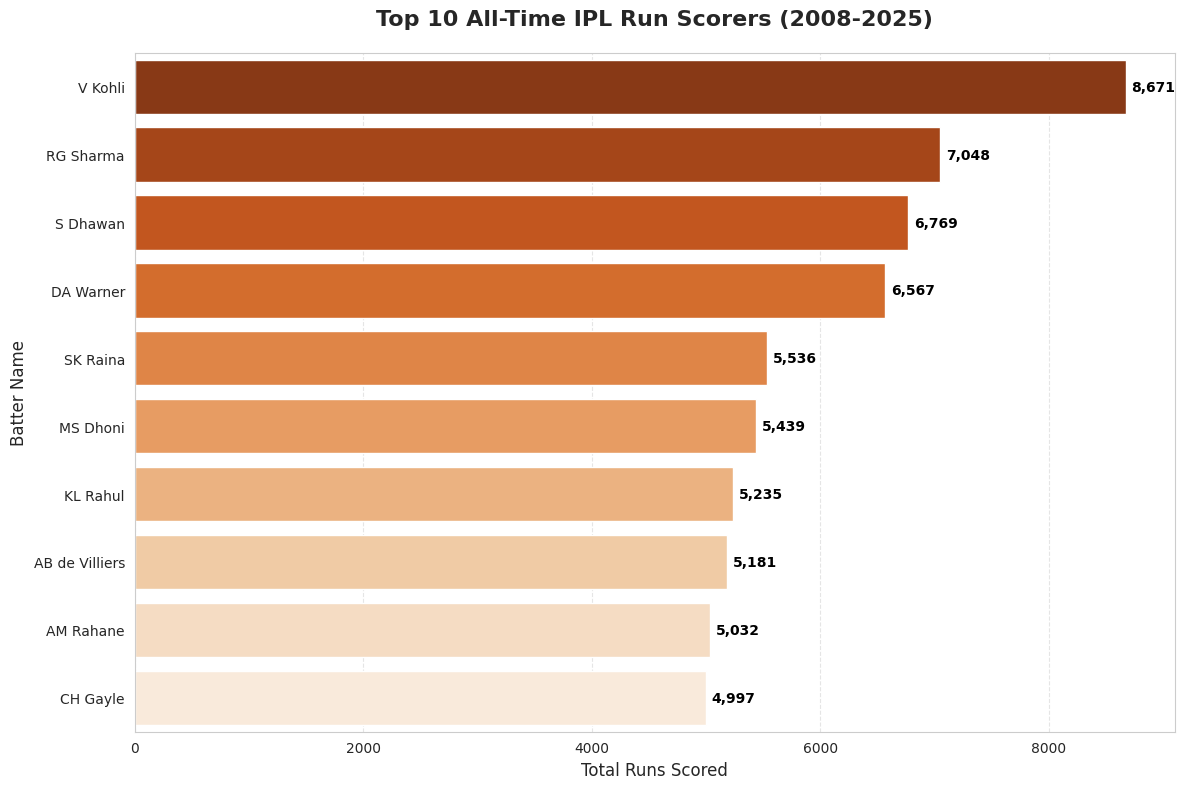

In [ ]:
# 2. Create Horizontal Bar Chart
plt.figure(figsize=(12, 8))

# Use 'Oranges_r' (with a capital O) for the professional gradient
ax = sns.barplot(data=top_batsmen, x='runs_batter', y='batter', palette='Oranges_r')

# 3. Add Professional Styling
plt.title('Top 10 All-Time IPL Run Scorers (2008-2025)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Total Runs Scored', fontsize=12)
plt.ylabel('Batter Name', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)

# 4. Add Data Labels at the end of each bar
for i, v in enumerate(top_batsmen['runs_batter']):
    plt.text(v + 50, i, f'{int(v):,}', color='black', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
# Filter for bowler-credited wickets
bowler_wickets = ['caught', 'bowled', 'lbw', 'stumped', 'caught and bowled', 'hit wicket']
top_bowlers = df_final[df_final['wicket_kind'].isin(bowler_wickets)].groupby('bowler')['wicket_kind'].count().sort_values(ascending=False).head(10)

top_bowlers

,wicket_kind
bowler,
YS Chahal,221
B Kumar,198
PP Chawla,192
SP Narine,192
R Ashwin,187
JJ Bumrah,186
DJ Bravo,183
A Mishra,174
RA Jadeja,170


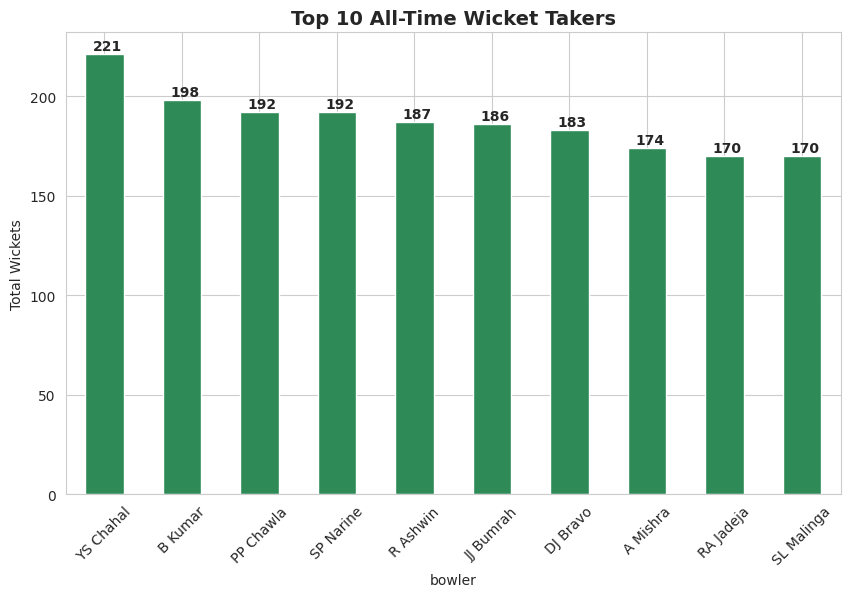

In [ ]:
plt.figure(figsize=(10, 6))
ax = top_bowlers.plot(kind='bar', color='seagreen')
plt.title('Top 10 All-Time Wicket Takers', fontsize=14, fontweight='bold')
plt.ylabel('Total Wickets')
plt.xticks(rotation=45)

for p in ax.patches:
    ax.annotate(str(int(p.get_height())), (p.get_x() + 0.1, p.get_height() + 2), fontweight='bold')

plt.show()

In [ ]:
# Grouping by match and innings to find the highest scores
high_scores = df_final.groupby(['match_id', 'season', 'batting_team','bowling_team','innings'])['runs_total'].sum().reset_index()
top_totals = high_scores.sort_values(by='runs_total', ascending=False).head(10)

print("🔥 HIGHEST TEAM TOTALS")
print(top_totals[['season', 'batting_team','bowling_team', 'runs_total']].to_string(index=False))

🔥 HIGHEST TEAM TOTALS
 season batting_team bowling_team  runs_total
   2024          SRH          RCB         287
   2025          SRH           RR         286
   2025          SRH          KKR         278
   2024          SRH           MI         277
   2024          KKR           DC         272
   2024          SRH           DC         266
   2013          RCB          PWI         263
   2024         PBKS          KKR         262
   2024          RCB          SRH         262
   2024          KKR         PBKS         261


<Figure size 1000x600 with 0 Axes>

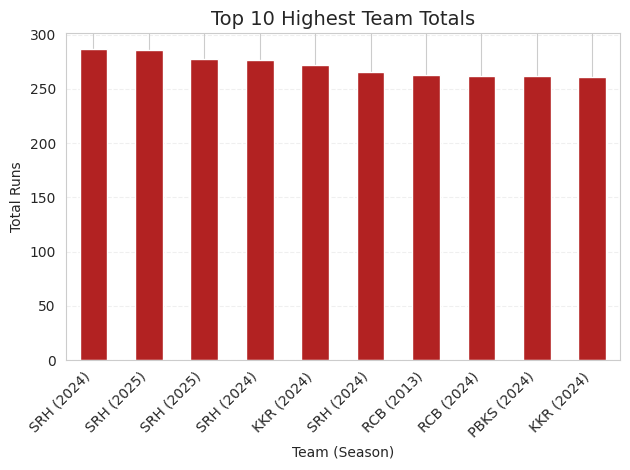

In [ ]:
# Create a simple label
top_totals['label'] = top_totals['batting_team'] + " (" + top_totals['season'].astype(str) + ")"

# Simple Pandas Bar Plot
plt.figure(figsize=(10, 6))
top_totals.plot(kind='bar', x='label', y='runs_total', color='firebrick', legend=False)

plt.title('Top 10 Highest Team Totals', fontsize=14)
plt.ylabel('Total Runs')
plt.xlabel('Team (Season)')
plt.xticks(rotation=45, ha='right') # Rotate and align labels to prevent cutting
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# 1. Calculate totals for every innings
match_totals = df_final.groupby(['match_id', 'innings', 'batting_team','bowling_team', 'winner'])['runs_total'].sum().reset_index()

# 2. Filter for 2nd Innings where the batting team won
chases = match_totals[(match_totals['innings'] == 2) & (match_totals['batting_team'] == match_totals['winner'])]

# 3. Sort by total runs
top_chases = chases.sort_values(by='runs_total', ascending=False).head(10)

print("🏃 HIGHEST SUCCESSFUL RUN CHASES")
print(top_chases[['batting_team','bowling_team', 'runs_total']].to_string(index=False))

🏃 HIGHEST SUCCESSFUL RUN CHASES
batting_team bowling_team  runs_total
        PBKS          KKR         262
         SRH         PBKS         247
         RCB          LSG         230
          RR         PBKS         226
          RR          KKR         224
          MI          CSK         219
         SRH           RR         217
          RR          SRH         217
          MI         PBKS         216
         SRH         PBKS         215


In [ ]:
# 1. Calculate totals for 1st innings of every match
match_innings_totals = df_final.groupby(['match_id', 'season', 'innings', 'batting_team', 'bowling_team', 'winner'])['runs_total'].sum().reset_index()

# 2. Filter for matches where:
# - It's the 1st innings
# - The team that batted first is the winner
defended_totals = match_innings_totals[(match_innings_totals['innings'] == 1) &
                                       (match_innings_totals['batting_team'] == match_innings_totals['winner'])]

# 3. Sort by the lowest runs to find the top 10 miracles
lowest_defended = defended_totals.sort_values(by='runs_total', ascending=True).head(10)

print("🛡️ LOWEST TOTALS DEFENDED (MIRACLE WINS)")
print(lowest_defended[['season', 'batting_team', 'runs_total', 'bowling_team']].to_string(index=False))


🛡️ LOWEST TOTALS DEFENDED (MIRACLE WINS)
 season batting_team  runs_total bowling_team
   2015         PBKS         106          RCB
   2013          RCB         106          CSK
   2025         PBKS         111          KKR
   2009          CSK         116         PBKS
   2018          SRH         118           MI
   2009         PBKS         119           MI
   2013          SRH         119          PWI
   2012           MI         120          PWI
   2021         PBKS         125          SRH
   2023          RCB         126          LSG


In [ ]:
# 1. Create the detailed display label including runs
lowest_defended['label'] = (
    lowest_defended['batting_team'] + " defended " +
    lowest_defended['runs_total'].astype(str) + " vs " +
    lowest_defended['bowling_team'] + " (" +
    lowest_defended['season'].astype(str) + ")"
)

# 2. Print the top 10 results without the index
print("🛡️ TOP 10 LOWEST TOTALS DEFENDED")
print("-" * 60)
print(lowest_defended[['label']].to_string(index=False))

🛡️ TOP 10 LOWEST TOTALS DEFENDED
------------------------------------------------------------
                          label
PBKS defended 106 vs RCB (2015)
 RCB defended 106 vs CSK (2013)
PBKS defended 111 vs KKR (2025)
CSK defended 116 vs PBKS (2009)
  SRH defended 118 vs MI (2018)
 PBKS defended 119 vs MI (2009)
 SRH defended 119 vs PWI (2013)
  MI defended 120 vs PWI (2012)
PBKS defended 125 vs SRH (2021)
 RCB defended 126 vs LSG (2023)


/tmp/ipykernel_1300/428727558.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=lowest_defended, x='runs_total', y='label', palette='mako')


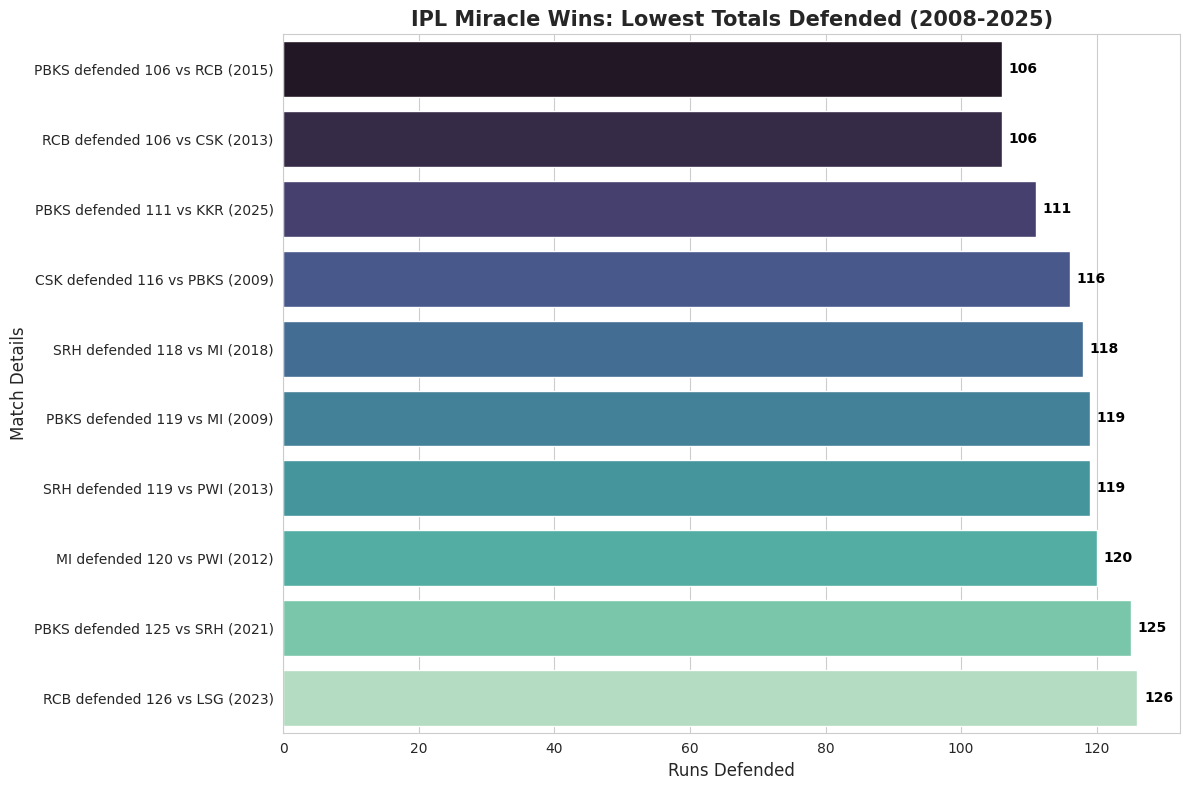

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))
ax = sns.barplot(data=lowest_defended, x='runs_total', y='label', palette='mako')

plt.title('IPL Miracle Wins: Lowest Totals Defended (2008-2025)', fontsize=15, fontweight='bold')
plt.xlabel('Runs Defended', fontsize=12)
plt.ylabel('Match Details', fontsize=12)

# Adding the run labels at the end of the bars
for i, v in enumerate(lowest_defended['runs_total']):
    ax.text(v + 1, i, str(int(v)), color='black', va='center', fontweight='bold')

plt.tight_layout()
plt.show()